# Task 1: Hierarchical Clustering in Non-Euclidean Spaces

**Course:** 504048 - Mining Massive Data Sets  
**Description:**  
This notebook implements agglomerative (bottom-up) hierarchical clustering on alphabetical strings  
using **Jaccard distance** over 4-shingle sets - a non-Euclidean distance metric.

**Cluster representation:** Approach 2 (cluster centroid = most-central point by average pairwise distance)  
**Termination:** When the maximum cluster diameter suddenly jumps (abnormal increase detection)  

---

## 0. Setup & Imports

In [ ]:
!pip install pyspark scikit-learn -q


In [ ]:
import random
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import lru_cache
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE

In [ ]:
from pyspark import SparkContext, SparkConf

conf = SparkConf().setAppName('Task1-HierarchicalClustering').setMaster('local[*]')
sc   = SparkContext.getOrCreate(conf)
sc.setLogLevel('ERROR')
print('SparkContext started:', sc.version)


## 1. Data: String Generation, Shingling & Jaccard Distance

- Generate **10,000 random lowercase alphabetical strings** with lengths in [32, 64].
- Apply **4-shingling** to tokenize each string into a set of 4-character substrings.
- Use **Jaccard distance** = 1 − |A ∩ B| / |A ∪ B| to measure dissimilarity.
- Save the dataset to a CSV file with columns: `index`, `string`, `shingles`.

In [ ]:
class StringDataset:
    """
    Generates a dataset of random lowercase alphabetical strings,
    applies k-shingling, and computes Jaccard distances between shingle sets.
    """

    def __init__(self, sc, n_samples=10000, min_len=32, max_len=64, k=4):
        self.sc = sc
        self.n_samples = n_samples
        self.min_len   = min_len
        self.max_len   = max_len
        self.k         = k
        self.data      = []   # list of (index, string)
        self.dataset   = []   # list of (index, string, shingles)

    # ------------------------------------------------------------------ #
    #  String generation
    # ------------------------------------------------------------------ #

    def _generate_string(self):
        """Return one random lowercase alphabetical string."""
        length = random.randint(self.min_len, self.max_len)
        return ''.join(random.choices(string.ascii_lowercase, k=length))

    def generate(self):
        """Generate n_samples random strings and store them with their indices."""
        rdd = self.sc.parallelize(range(self.n_samples))
        self.data = rdd.map(lambda i: (i, self._generate_string())).collect()
        print(f"[+] Generated {len(self.data):,} strings.")

    # ------------------------------------------------------------------ #
    #  Shingling
    # ------------------------------------------------------------------ #

    def _shingle(self, s):
        """Return the set of k-shingles for string s."""
        return frozenset(s[i:i + self.k] for i in range(len(s) - self.k + 1))

    def apply_shingling(self):
        """Apply k-shingling to every string in the dataset."""
        rdd = self.sc.parallelize(self.data)
        self.dataset = rdd.map(lambda tup: (tup[0], tup[1], self._shingle(tup[1]))).collect()
        print(f"[+] {self.k}-shingling applied to all strings.")

    # ------------------------------------------------------------------ #
    #  Jaccard distance  (cached for repeated lookups)
    # ------------------------------------------------------------------ #

    @staticmethod
    @lru_cache(maxsize=None)
    def jaccard_distance(s1: tuple, s2: tuple) -> float:
        """
        Jaccard distance between two shingle sets passed as sorted tuples
        (tuples are hashable, required for lru_cache).
        """
        a, b = set(s1), set(s2)
        intersection = len(a & b)
        union        = len(a | b)
        return 1.0 - intersection / union if union > 0 else 0.0

    def distance(self, shingles1, shingles2) -> float:
        """Convenience wrapper: accepts frozensets and converts to sorted tuples."""
        return self.jaccard_distance(tuple(sorted(shingles1)),
                                     tuple(sorted(shingles2)))

    # ------------------------------------------------------------------ #
    #  Persistence
    # ------------------------------------------------------------------ #

    def save_to_csv(self, filename="dataset.csv"):
        """Save the dataset (index, string, shingles) to a CSV file."""
        rows = [(idx, s, list(sh)) for idx, s, sh in self.dataset]
        df   = pd.DataFrame(rows, columns=["index", "string", "shingles"])
        df.to_csv(filename, index=False)
        print(f"[+] Dataset saved -> {filename}")

    # ------------------------------------------------------------------ #
    #  Utilities
    # ------------------------------------------------------------------ #

    def get_subset(self, size=800):
        """Return a random subset of `size` records from the full dataset."""
        return random.sample(self.dataset, size)

    def show_random_sample(self, max_shingles=10):
        """Print a randomly chosen record for quick inspection."""
        idx, s, shingles = random.choice(self.dataset)
        shown = list(shingles)[:max_shingles]
        print(f"Index  : {idx}")
        print(f"String : {s}")
        print(f"Shingles (first {max_shingles}):")
        for sh in shown:
            print(f"  - {sh}")

In [ ]:
# Build the dataset
dataset = StringDataset(sc, n_samples=10000)
dataset.generate()
dataset.apply_shingling()
dataset.save_to_csv("dataset.csv")

# Draw a subset that will be used for clustering
sample_data = dataset.get_subset(800)

print("\n--- Random sample ---")
dataset.show_random_sample()

[+] Generated 10,000 strings.
[+] 4-shingling applied to all strings.
[+] Dataset saved -> dataset.csv

--- Random sample ---
Index  : 8393
String : llvxogfwrvssukmeuxnikelwetzcaipopdml
Shingles (first 10):
  - ssuk
  - opdm
  - wetz
  - tzca
  - nike
  - euxn
  - sukm
  - caip
  - uxni
  - fwrv


## 2. Algorithm: Agglomerative Clustering (Approach 2, Non-Euclidean)

**Approach 2** (from lecture):  
- Each cluster is **represented by its centroid** - the point whose average Jaccard distance  
  to all other points in the cluster is minimised.  
- **Cluster distance** = Jaccard distance between the centroids of two clusters.

**Termination:**  
The algorithm stops when the **maximum cluster diameter** increases by a factor ≥ `jump_factor`  
compared to the previous step (sudden jump detection), OR when no pair of clusters  
satisfies the distance threshold `t`.

In [ ]:
class AgglomerativeClustering:
    """
    Bottom-up agglomerative clustering over Jaccard-distance shingle sets.

    Cluster representation  : Approach 2 - centroid is the point with the
                               smallest average pairwise Jaccard distance to
                               all other cluster members.
    Cluster distance        : Jaccard distance between cluster centroids.
    Termination condition   : distance > threshold  OR  diameter jump detected.
    """

    def __init__(self, sc, data, threshold=0.6, jump_factor=1.5, max_checks=2000,
                 centroid_sample=10):
        """
        Parameters
        ----------
        sc             : SparkContext
        data           : list of (index, string, frozenset_of_shingles)
        threshold      : merge only if cluster distance <= threshold
        jump_factor    : stop if max_diameter grows by this factor between steps
        max_checks     : max cluster pairs evaluated per step (speed / accuracy trade-off)
        centroid_sample: number of random pairs used to estimate avg intra-cluster distance
        """
        self.sc              = sc
        self.clusters        = [[p] for p in data]  # start: each point is its own cluster
        self.threshold       = threshold
        self.jump_factor     = jump_factor
        self.max_checks      = max_checks
        self.centroid_sample = centroid_sample

        # History recorded per merge step
        self.merge_distances  = []   # distance at which clusters were merged
        self.global_avg_dists = []   # global_avg_dist after each merge
        self.max_diameters    = []   # max cluster diameter after each merge

    # ------------------------------------------------------------------ #
    #  Intra-cluster statistics
    # ------------------------------------------------------------------ #

    def avg_cluster_distance(self, cluster, n_samples=None):
        """
        Estimate the average pairwise Jaccard distance within `cluster`
        by drawing `n_samples` random pairs.

        Returns 0.0 for singleton clusters.
        """
        if len(cluster) < 2:
            return 0.0
        n = n_samples or self.centroid_sample
        dists = [
            StringDataset.jaccard_distance(
                tuple(sorted(random.choice(cluster)[2])),
                tuple(sorted(random.choice(cluster)[2]))
            )
            for _ in range(n)
        ]
        return sum(dists) / len(dists)

    def compute_global_avg(self):
        """
        Compute the mean of avg_cluster_distance across all non-singleton clusters.
        Parallelised over an RDD; returns 0.0 if there are no multi-point clusters.
        """
        multi = [c for c in self.clusters if len(c) > 1]
        if not multi:
            return 0.0
        vals = self.sc.parallelize(multi).map(self.avg_cluster_distance).collect()
        return sum(vals) / len(vals)

    def cluster_diameter(self, cluster, n_samples=None):
        """
        Estimate the diameter (maximum pairwise distance) of `cluster`
        via random sampling.
        """
        if len(cluster) < 2:
            return 0.0
        n = n_samples or self.centroid_sample
        dists = [
            StringDataset.jaccard_distance(
                tuple(sorted(random.choice(cluster)[2])),
                tuple(sorted(random.choice(cluster)[2]))
            )
            for _ in range(n)
        ]
        return max(dists)

    def max_cluster_diameter(self):
        """Return the maximum diameter across all clusters, computed via RDD map."""
        if not self.clusters:
            return 0.0
        return self.sc.parallelize(self.clusters) \
                      .map(self.cluster_diameter) \
                      .max()

    # ------------------------------------------------------------------ #
    #  Centroid (Approach 2)
    # ------------------------------------------------------------------ #

    def centroid(self, cluster):
        """
        Return the point in `cluster` with the smallest average Jaccard
        distance to all other cluster members (Approach 2).
        """
        if len(cluster) == 1:
            return cluster[0]
        best_point, best_avg = None, float('inf')
        for candidate in cluster:
            sh_c = tuple(sorted(candidate[2]))
            avg  = sum(
                StringDataset.jaccard_distance(sh_c, tuple(sorted(other[2])))
                for other in cluster if other is not candidate
            ) / (len(cluster) - 1)
            if avg < best_avg:
                best_avg, best_point = avg, candidate
        return best_point

    # ------------------------------------------------------------------ #
    #  Inter-cluster distance (centroid-to-centroid)
    # ------------------------------------------------------------------ #

    def cluster_distance(self, c1, c2):
        """
        Jaccard distance between the centroids of clusters c1 and c2.
        Uses random sampling to approximate centroids for large clusters.
        """
        def approx_centroid(cluster):
            if len(cluster) <= self.centroid_sample:
                return self.centroid(cluster)
            sample = random.sample(cluster, self.centroid_sample)
            return self.centroid(sample)

        p1 = approx_centroid(c1)
        p2 = approx_centroid(c2)
        return StringDataset.jaccard_distance(
            tuple(sorted(p1[2])),
            tuple(sorted(p2[2]))
        )

    # ------------------------------------------------------------------ #
    #  Closest pair search  (distributed via RDD cartesian)
    # ------------------------------------------------------------------ #

    def find_closest_clusters(self):
        """
        Find the pair of clusters with the smallest inter-centroid distance.

        Uses RDD.cartesian() to distribute pair evaluation across workers.
        Returns (pair_indices, min_distance), or (None, inf) if no clusters remain.
        """
        if len(self.clusters) < 2:
            return None, float('inf')

        indexed = [(i, self.clusters[i]) for i in range(len(self.clusters))]
        clusters_rdd = self.sc.parallelize(indexed)

        result = (
            clusters_rdd
            .cartesian(clusters_rdd)
            .filter(lambda x: x[0][0] < x[1][0])
            .map(lambda x: ((x[0][0], x[1][0]),
                            self.cluster_distance(x[0][1], x[1][1])))
            .takeOrdered(1, key=lambda x: x[1])
        )

        if not result:
            return None, float('inf')
        best_pair, min_dist = result[0]
        return best_pair, min_dist

    # ------------------------------------------------------------------ #
    #  Diameter-jump detection
    # ------------------------------------------------------------------ #

    def detect_diameter_jump(self):
        """
        Return True if the maximum cluster diameter increased by a factor
        of at least `jump_factor` compared to the previous step.
        """
        if len(self.max_diameters) < 2:
            return False
        prev, curr = self.max_diameters[-2], self.max_diameters[-1]
        return prev > 0 and curr >= self.jump_factor * prev

    # ------------------------------------------------------------------ #
    #  Main fit loop
    # ------------------------------------------------------------------ #

    def fit(self):
        """
        Execute the agglomerative clustering algorithm until termination.

        Termination conditions:
          1. No remaining pair satisfies the distance threshold.
          2. The maximum cluster diameter suddenly jumps.

        Returns the final list of clusters.
        """
        step = 0

        while True:
            pair, dist = self.find_closest_clusters()

            # --- Condition 1: no valid pair left ---
            if pair is None:
                print("[STOP] No more cluster pairs found.")
                break

            # --- Condition 1 (threshold): best distance exceeds threshold ---
            if dist > self.threshold:
                print(f"[STOP] Min distance {dist:.4f} exceeds threshold {self.threshold}.")
                break

            # Merge the two closest clusters
            i, j = pair
            self.clusters[i] = self.clusters[i] + self.clusters[j]
            del self.clusters[j]

            # Record per-step statistics
            self.merge_distances.append(dist)
            self.global_avg_dists.append(self.compute_global_avg())
            self.max_diameters.append(self.max_cluster_diameter())

            step += 1

            if step % 50 == 0 or step == 1:
                print(f"Step {step:>4d} | merge_dist={dist:.4f} "
                      f"| global_avg={self.global_avg_dists[-1]:.4f} "
                      f"| clusters={len(self.clusters)}")

            # --- Condition 2: diameter jump ---
            if self.detect_diameter_jump():
                print(f"[STOP] Diameter jump detected at step {step} "
                      f"(factor >= {self.jump_factor}).")
                break

        print(f"\nFinal cluster count: {len(self.clusters)}")
        return self.clusters


In [ ]:
# Run clustering on the 800-point subset
model    = AgglomerativeClustering(sc, sample_data, threshold=1.0, jump_factor=1.5)
clusters = model.fit()


Step    1 | merge_dist=0.9785 | global_avg=0.5871 | clusters=799
Step   50 | merge_dist=0.9903 | global_avg=0.7970 | clusters=750
Step  100 | merge_dist=1.0000 | global_avg=0.9463 | clusters=700
Step  150 | merge_dist=0.9891 | global_avg=0.7306 | clusters=650
Step  200 | merge_dist=0.9794 | global_avg=0.6465 | clusters=600
Step  250 | merge_dist=0.9873 | global_avg=0.8459 | clusters=550
Step  300 | merge_dist=0.9906 | global_avg=0.6473 | clusters=500
Step  350 | merge_dist=0.9877 | global_avg=0.7359 | clusters=450
Step  400 | merge_dist=0.9846 | global_avg=0.6569 | clusters=400
Step  450 | merge_dist=0.9900 | global_avg=0.4723 | clusters=350
Step  500 | merge_dist=0.9907 | global_avg=0.6293 | clusters=300
Step  550 | merge_dist=0.9882 | global_avg=0.7243 | clusters=250
Step  600 | merge_dist=0.9889 | global_avg=0.5455 | clusters=200
Step  650 | merge_dist=1.0000 | global_avg=0.6098 | clusters=150
Step  700 | merge_dist=0.9875 | global_avg=0.4834 | clusters=100
Step  750 | merge_dist=1.

## 3. Experiments

### 3a. Global Average Distance Over Merge Steps

At each step we compute:  
- **`avg_dist`** - average pairwise Jaccard distance within each cluster  
- **`global_avg_dist`** - mean of all per-cluster `avg_dist` values  

The line chart below shows how `global_avg_dist` evolves across steps.

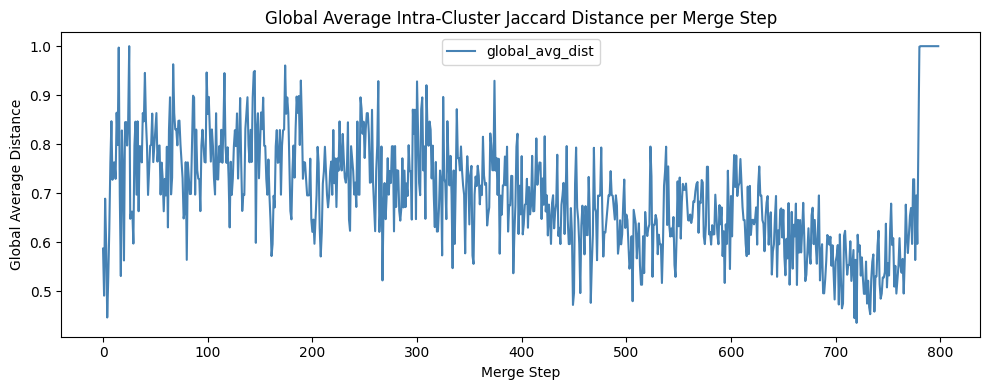

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(model.global_avg_dists, color='steelblue', linewidth=1.5, label='global_avg_dist')
plt.xlabel('Merge Step')
plt.ylabel('Global Average Distance')
plt.title('Global Average Intra-Cluster Jaccard Distance per Merge Step')
plt.legend()
plt.tight_layout()
plt.show()

### 3b. t-SNE 3D Visualisation of Clustering Result

We vectorise each string's shingle set into a binary BoW vector over a shared vocabulary,  
reduce to 3D with t-SNE, and colour points by their assigned cluster.

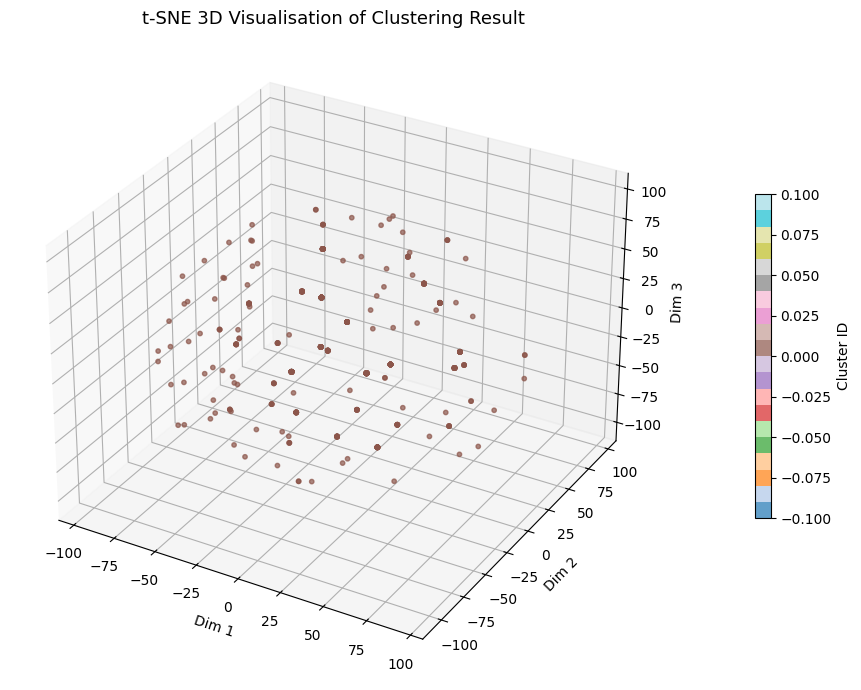

In [ ]:
# --- Prepare subset and vocabulary ---
TSNE_SUBSET_SIZE = 500          # keep manageable for t-SNE
MAX_VOCAB_SIZE   = 2000

tsne_points = sample_data[:TSNE_SUBSET_SIZE]

# Build vocabulary from the subset
vocab_set = set()
for _, _, shingles in tsne_points:
    vocab_set.update(shingles)
vocab      = list(vocab_set)[:MAX_VOCAB_SIZE]
vocab_idx  = {v: i for i, v in enumerate(vocab)}

def vectorize(shingles):
    """Binary BoW vector over the shared vocabulary."""
    vec = [0] * len(vocab)
    for s in shingles:
        if s in vocab_idx:
            vec[vocab_idx[s]] = 1
    return vec

X = np.array([vectorize(sh) for _, _, sh in tsne_points])

# --- Build a point-to-cluster-id mapping for colouring ---
point_to_cluster = {}
for cid, cluster in enumerate(clusters):
    for point in cluster:
        point_to_cluster[point[0]] = cid   # keyed by original index

colors = [
    point_to_cluster.get(idx, -1)
    for idx, _, _ in tsne_points
]

# --- t-SNE ---
tsne      = TSNE(n_components=3, perplexity=30, random_state=42)
X_embedded = tsne.fit_transform(X)

# --- 3D scatter ---
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

scatter_plot = ax.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    X_embedded[:, 2],
    c=colors,
    cmap='tab20',
    s=10,
    alpha=0.7
)

ax.set_title('t-SNE 3D Visualisation of Clustering Result', fontsize=13)
ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
ax.set_zlabel('Dim 3')
plt.colorbar(scatter_plot, ax=ax, label='Cluster ID', shrink=0.5, pad=0.1)
plt.tight_layout()
plt.show()